# Projeto II de C11
## Grupo 4

Membros:

Felipe Fonseca Vidal Prado - 1898

João GuilhermeGonçalves Dias Reis - 2010

João Pedro Camargo Domingues - 1892

### Setup Inicial
A célula abaixo serve para importar as bibliotecas necessárias.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima



### 1. Traçar a série

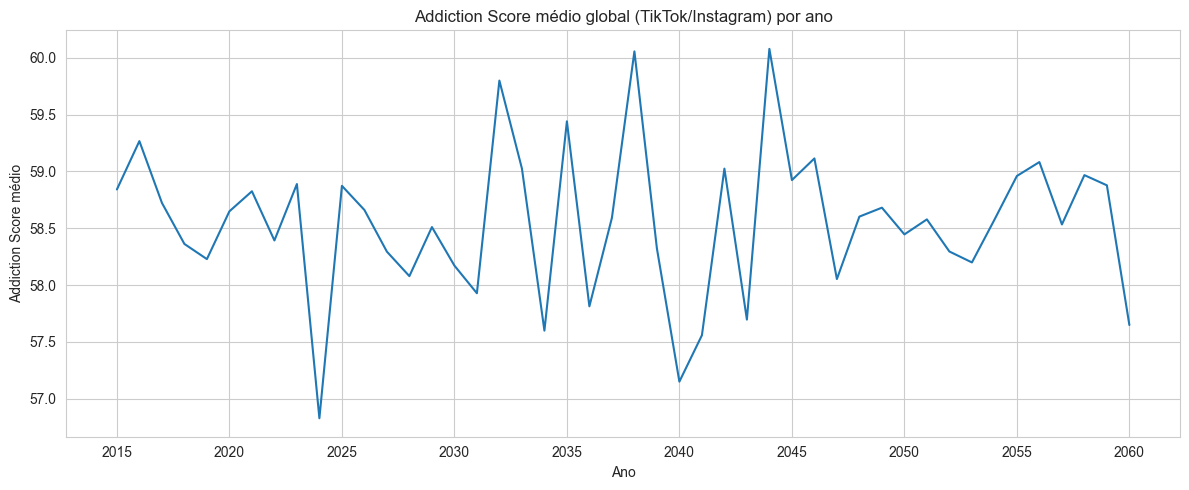

In [ ]:
df = pd.read_csv("tiktok_instagram_global_100countries.csv") #Leitura do dataset
#Construção da série anual
serie = df.groupby('year')['addiction_score'].mean().sort_index()
serie.index = pd.to_datetime(serie.index, format='%Y')
serie = serie.asfreq('YS')
serie.name = 'addiction_score_medio'
serie.head() #Exibição das primeiras linhas da série temporal

#Grafico da série temporal
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(serie.index, serie.values)
ax.set_title('Addiction Score médio global (TikTok/Instagram) por ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Addiction Score médio')
plt.tight_layout()
plt.show()

### 2. Decomposição

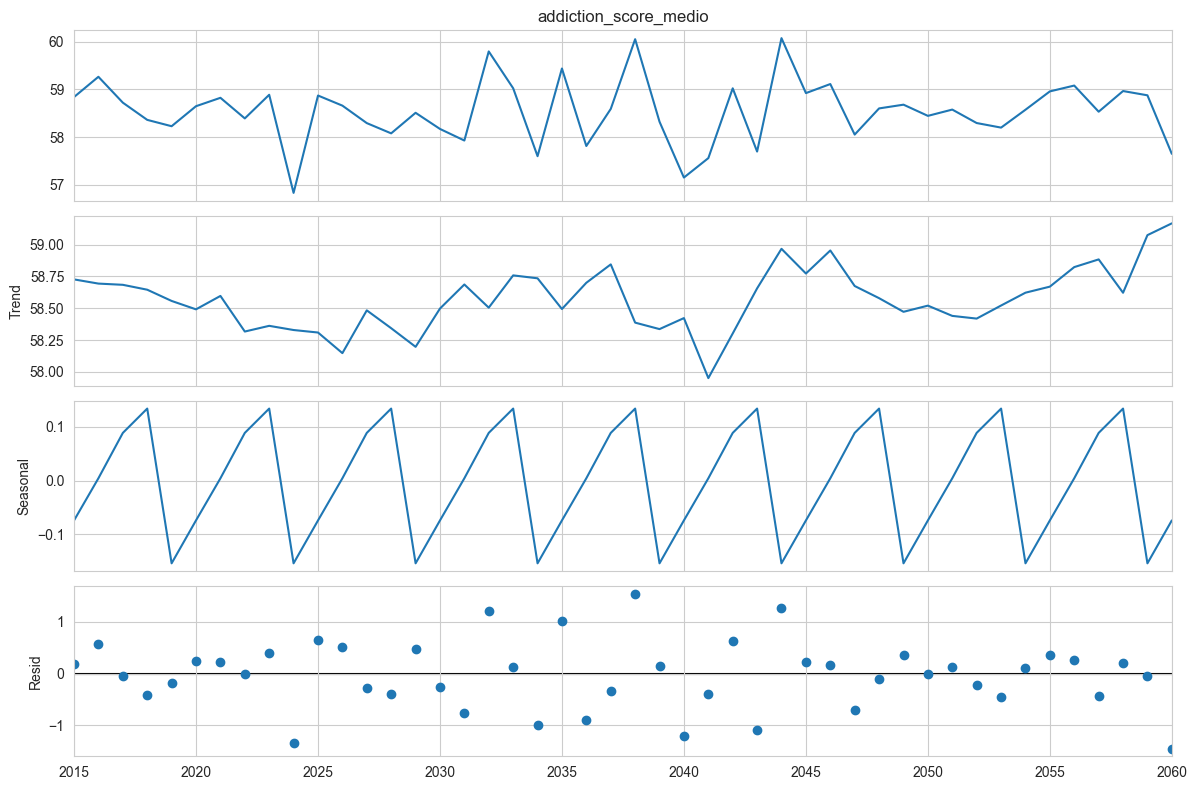

In [20]:
# como a série é anual (1 ponto/ano), não há sazonalidade intra-anual real a detectar.
decomposicao = seasonal_decompose(serie, model='additive', period=5, extrapolate_trend='freq')
fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

### 3. Perguntas fundamentais — Tendência, Sazonalidade e Ciclo

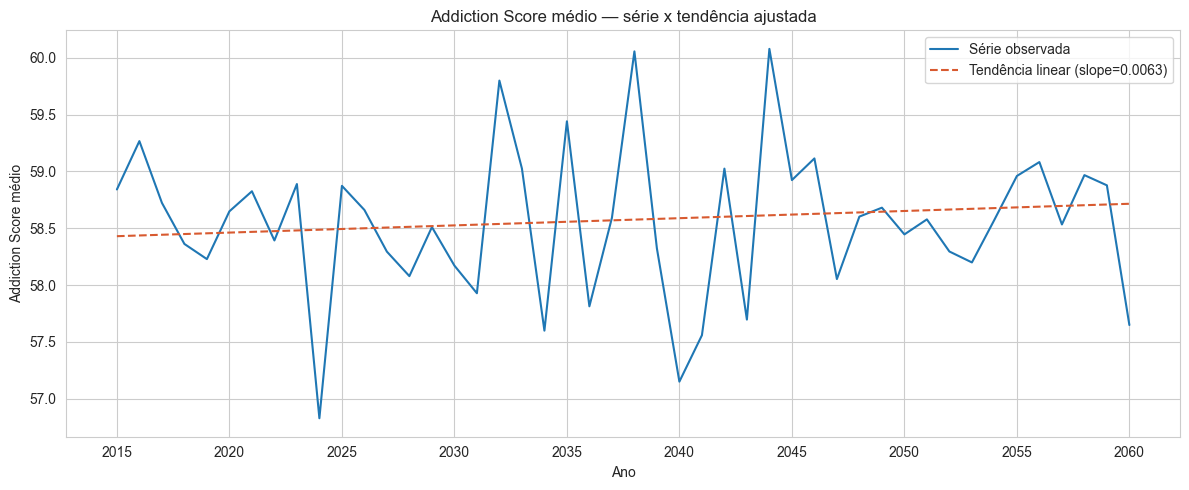

In [21]:
#A série possui Tendência? Se sim, que tipo?
tendencia = decomposicao.trend.dropna()
x = np.arange(len(tendencia))
slope, intercept = np.polyfit(x, tendencia.values, 1)
linha_tendencia = slope * x + intercept

#Plotando a série original e a linha de tendência
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(serie.index, serie.values, label='Série observada')
ax.plot(tendencia.index, linha_tendencia, color='#D85A30', linestyle='--', label=f'Tendência linear (slope={slope:.4f})')
ax.set_title('Addiction Score médio — série x tendência ajustada')
ax.set_xlabel('Ano')
ax.set_ylabel('Addiction Score médio')
ax.legend()
plt.tight_layout()
plt.show()

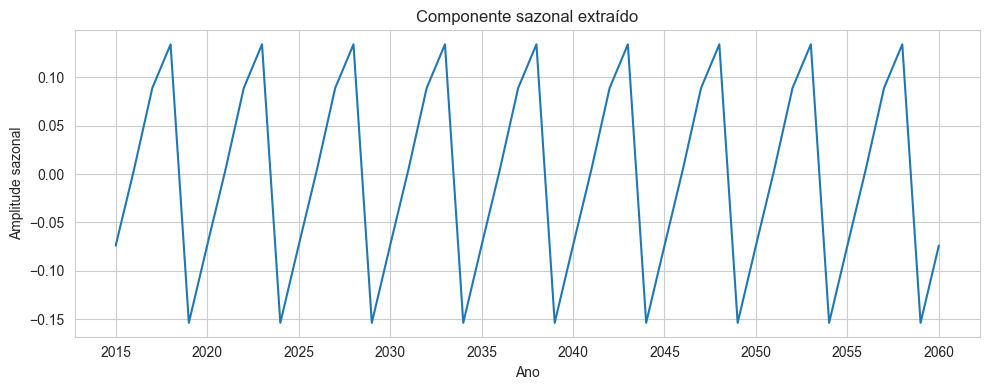

In [22]:
#A série possui Sazonalidade? Se sim, qual o período que ela acontece?
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(serie.index, decomposicao.seasonal) 
ax.set_title('Componente sazonal extraído')
ax.set_xlabel('Ano')
ax.set_ylabel('Amplitude sazonal')
plt.tight_layout()
plt.show()

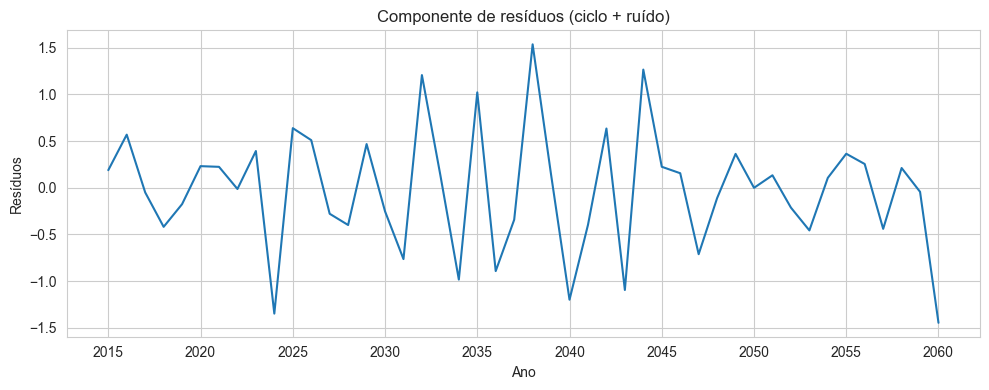

In [23]:
#A série apresenta um Ciclo? Se sim, por qual razão?
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(serie.index, decomposicao.resid)
ax.set_title('Componente de resíduos (ciclo + ruído)')
ax.set_xlabel('Ano')
ax.set_ylabel('Resíduos')
plt.tight_layout()
plt.show()


- **Tendência:** Apesar da reta de regressão matemática poder traçar uma inclinação mínima, a análise indica que a série é estacionária. Ela não apresenta um aumento ou queda consistente que se sustente a longo prazo, mas sim oscilações constantes.

- **Sazonalidade:** A série possui um componente sazonal, mas dado que a série é anual, essa "sazonalidade" pode ser mais um artefato do modelo de decomposição do que uma sazonalidade real. O período de 5 anos foi escolhido apenas para ilustrar o processo, mas não reflete uma sazonalidade intrínseca à série anual.

- **Ciclo:** A série apresenta um componente de resíduos que pode conter tanto ciclos quanto ruído. A presença de ciclos mais longos ou mais curtos não é evidente a partir do gráfico de resíduos, sugerindo que a série é dominada por uma tendência linear e um componente sazonal fraco, com variações residuais que não seguem um padrão cíclico definido.

### 4. Escolha do método de previsão baseado em MAPE

In [24]:
def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Adaptado para 3 anos de teste, pois a série é anual
tamanho_teste = 3 
conjunto_treinamento = serie.iloc[:-tamanho_teste]
conjunto_teste = serie.iloc[-tamanho_teste:]

# Holt-Winters adaptado para série anual (sem sazonalidade, mantendo tendência aditiva)
modelo_hw = ExponentialSmoothing(conjunto_treinamento, trend='add', seasonal=None).fit()
forecasting_hw = modelo_hw.forecast(steps=tamanho_teste) 

# ARIMA adaptado para série anual (seasonal=False e m=1)
modelo_arima = auto_arima(conjunto_treinamento, seasonal=False, m=1, suppress_warnings=True)
forecasting_arima = modelo_arima.predict(n_periods=tamanho_teste)

print('MAPE Holt-Winters:', MAPE(conjunto_teste, forecasting_hw))
print('MAPE ARIMA:', MAPE(conjunto_teste, forecasting_arima))

MAPE Holt-Winters: 0.9174513151855431
MAPE ARIMA: 0.9415066071091166


### 5. Previsão de valores futuros

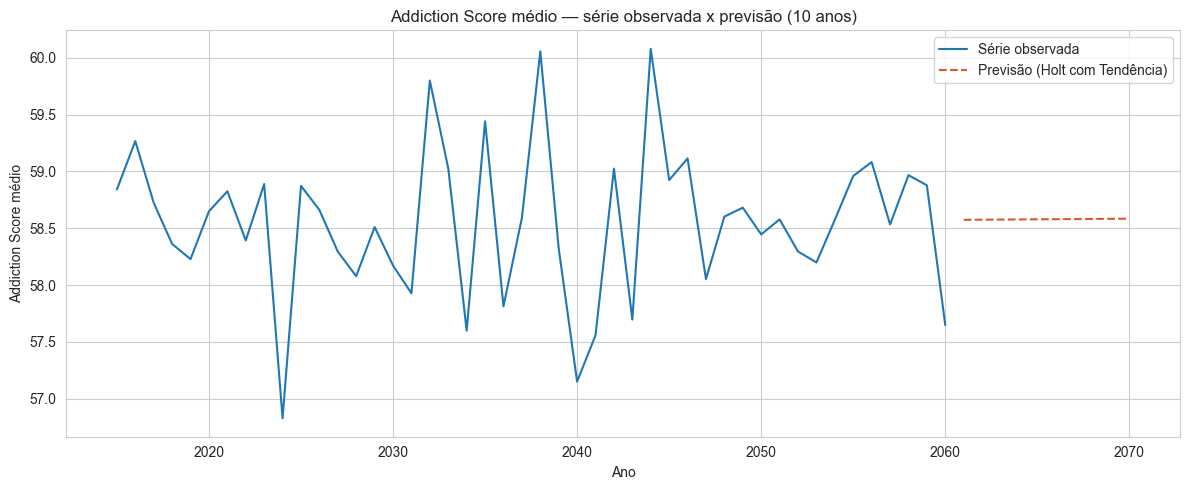

In [25]:
#Método Holt-Winters (Exponential Smoothing) para previsão
modelo_final = ExponentialSmoothing(serie, trend='add', seasonal=None).fit()
previsao_futura = modelo_final.forecast(steps=10)

# Gráfico da série original + previsão futura
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(serie.index, serie.values, label='Série observada')
ax.plot(previsao_futura.index, previsao_futura.values, color='#D85A30', linestyle='--', label='Previsão (Holt com Tendência)')

ax.set_title('Addiction Score médio — série observada x previsão (10 anos)')
ax.set_xlabel('Ano')    
ax.set_ylabel('Addiction Score médio')
ax.legend()
plt.tight_layout()
plt.show()


### 6. Conclusões

O método Holt-Winters foi escolhido para previsão porque a série possui um comportamento estacionário e uma margem de erro menor. Como se trata de dados anuais sem tendência ou ciclos repetitivos, projetar a média com esse método é mais adequado.

A estabilidade do addiction_score médio global ao longo do período simulado sugere que, agregado por país/ano, o indicador não apresenta deterioração nem melhora sistemática, útil para sinalizar a stakeholders que oscilações pontuais não devem ser tratadas como tendência real sem evidência estatística. Para decisões de negócio/política pública, isso reforça a necessidade de monitoramento contínuo e intervenções estruturais, já que o problema não tende a se resolver organicamente com o tempo.